# Q-ball Profiles and 2D Ansatz Preparation

This notebook works through the Q-ball / Q-cloud setup on the logistic potential in `Q_ball_finder/`. It is not part of the main `Bubble_finder/` analysis for *Globally Charged Vacuum Decay* ([arXiv:2606.21653](https://arxiv.org/abs/2606.21653)), but it documents the Q-ball branch and the shared grid/Newton infrastructure. The workflow is:

1. Specify model parameters and visualise the potential.
2. Solve for the metastable Q-ball profile and compute its charge and energy.
3. Determine the matching Q-cloud profile with the same charge.
4. Perform a frequency scan to explore the Q-ball solution branches and identify the critical point.
5. Analyze stability properties using the normalized energy vs charge plot.
6. Extract the unstable eigenmode around the Q-cloud and inspect its structure, including the shooting function.
7. Assemble the two-dimensional initial ansatz for the full bounce, plotting both the complex fields and the density $\rho(r,\tau)=\sqrt{\phi\bar\phi}$.

The calculations use the modules in `Q_ball_finder/`.

## Configuration

All parameters are centralized here. Modify these values to explore different configurations.


In [ ]:
# ============================================================================
# Configuration Section
# ============================================================================

import sys
from pathlib import Path

# Setup project path
def find_qubble_root(start: Path) -> Path:
    """Return the repository root containing Bubble_finder/ and Q_ball_finder/."""
    cur = start.resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "Bubble_finder").is_dir() and (parent / "Q_ball_finder").is_dir():
            return parent
    raise RuntimeError(
        "Could not locate the Qubble repository root. "
        "Run this notebook from inside the repository checkout."
    )

QUBBLE_ROOT = find_qubble_root(Path.cwd())
if str(QUBBLE_ROOT) not in sys.path:
    sys.path.insert(0, str(QUBBLE_ROOT))

# Model parameters
M = 1.0  # Mass scale
V = 1.0  # VEV scale  
B = 8.0  # Potential shape parameter

# Q-ball frequency (metastable branch)
OMEGA_QBALL_RATIO = 0.8755  # ω/m for metastable Q-ball

# Grid parameters for 2D ansatz
GRID_NR = 150      # Number of radial points
GRID_NTAU = 300    # Number of tau points
GRID_LR = 10.0     # Radial domain size

# Ansatz parameters
ANSATZ_AMPLITUDE = 6.0      # Negative mode amplitude
ANSATZ_COSH_SCALE = 3.0     # Cosh envelope scale

# Q-cloud scan parameters
QCLOUD_OMEGA_MIN_RATIO = 0.959716  # Minimum ω/m for Q-cloud scan
QCLOUD_OMEGA_MAX_RATIO = 0.999     # Maximum ω/m for Q-cloud scan
QCLOUD_N_POINTS = 60               # Number of scan points

print(f"Configuration loaded:")
print(f"  Qubble root: {QUBBLE_ROOT}")
print(f"  Model: m={M}, v={V}, b={B}")
print(f"  Q-ball frequency: ω/m = {OMEGA_QBALL_RATIO}")

In [ ]:
# ============================================================================
# Imports
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib for publication-quality figures
import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{siunitx}",
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20,
})
plt.rcParams["figure.figsize"] = (7, 4.8)

# Import Q_ball_finder library functions
from Q_ball_finder import (
    LogisticPotentialParams,
    build_negative_mode_ansatz,
    build_custom_rho_ansatz_qball2d,
    build_qcloud_profile_for_charge,
    build_grid,
    compute_dimensionless_charge,
    compute_energy,
    compute_unstable_mode,
    logistic_potential_chi,
    solve_qball_profile,
)

print("Imports completed successfully.")


Imports completed successfully.


## Model Parameters and Potential

The logarithmic potential used in this analysis is:

$$V(\rho) = -\frac{m^2 v^2}{b} \log\left(e^{-b \rho / v^2} + \frac{e^{-b}}{1 + e^{-b}}\right), \qquad \rho = |\phi|^2$$

where $m$ is the mass scale, $v$ is the VEV, and $b$ controls the potential shape. This form is convenient for Q-ball solutions while retaining analytic control.

For Q-ball solutions at frequency $\omega$, we work with the effective potential:

$$\hat{V}(|\phi|) = V(|\phi|) - \frac{1}{2}\omega^2 |\phi|^2$$

The Q-ball profile $\chi(r) = |\phi(r)|$ satisfies the radial bounce equation in this effective potential.


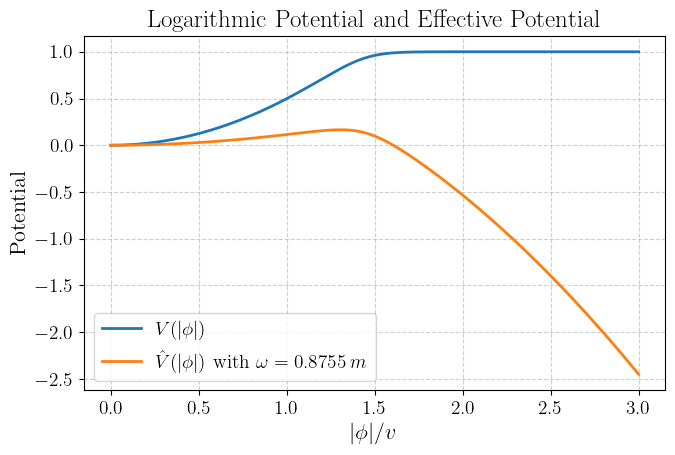

In [3]:
# Create potential parameters from configuration
params = LogisticPotentialParams(m=M, v=V, b=B)
omega_qball = OMEGA_QBALL_RATIO * params.m

# Get potential functions from library
V_chi, dV_dchi, _ = logistic_potential_chi(params)

# Plot potential and effective potential
chis = np.linspace(0.0, 3.0 * params.v, 400)
potential_vals = np.array([V_chi(chi) for chi in chis])
effective_vals = potential_vals - 0.5 * (omega_qball ** 2) * chis ** 2

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(chis / params.v, potential_vals, label=r"$V(|\phi|)$", lw=2)
ax.plot(chis / params.v, effective_vals, 
        label=rf"$\hat{{V}}(|\phi|)$ with $\omega={omega_qball/params.m:.4f}\,m$", lw=2)
ax.set_xlabel(r"$|\phi|/v$")
ax.set_ylabel(r"Potential")
ax.set_title("Logarithmic Potential and Effective Potential")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


## Metastable Q-ball Solution

We solve the radial bounce equation for the Q-ball profile $\chi(r)$ at frequency $\omega$. The profile satisfies:

$$\frac{d^2\chi}{dr^2} + \frac{2}{r}\frac{d\chi}{dr} = \frac{\partial \hat{V}}{\partial \chi}$$

with boundary conditions $\chi'(0) = 0$ and $\chi(\infty) = 0$.

From the numerical profile, we compute:
- **Dimensionless charge**: $g^2 Q = 4\pi (\omega/m) \int dr\, r^2 \phi^2$ where $\phi = \chi/v$
- **Energy above vacuum**: $E = 4\pi \int dr\, r^2 \left[\frac{1}{2}(\partial_r\chi)^2 + \frac{1}{2}\omega^2\chi^2 + (V(\chi) - V(0))\right]$

These observables provide target values for matching the Q-cloud and subsequent 2D bounce solutions.


In [4]:
# Solve for Q-ball profile using library function
qball_profile = solve_qball_profile(params, omega_qball)
qball_solution = qball_profile.solution

# Compute observables using library functions
g2Q_target = compute_dimensionless_charge(
    qball_solution, 
    m=params.m, 
    v=params.v, 
    omega=omega_qball
)
E_Q = compute_energy(
    qball_solution, 
    omega=omega_qball, 
    potential_chi=V_chi
)

print(f"Q-ball solution computed:")
print(f"  g²Q (dimensionless charge) = {g2Q_target:.6f}")
print(f"  E_Q (energy above vacuum)  = {E_Q:.6f}")
print(f"  ω/m                        = {omega_qball/params.m:.6f}")


Q-ball solution computed:
  g²Q (dimensionless charge) = 354.631864
  E_Q (energy above vacuum)  = 365.115638
  ω/m                        = 0.875500


## Matching Q-cloud Solution

To study the decay from the metastable Q-ball to the true vacuum, we need the Q-cloud configuration with the **same** conserved charge $g^2 Q$ as the Q-ball. The Q-cloud is the unstable branch of Q-ball solutions (at higher frequency $\omega$).

The function `build_qcloud_profile_for_charge` performs a frequency scan and interpolates to find the $\omega$ value that reproduces the target charge. This avoids solving the full scan from scratch each time.

We plot both Q-ball and Q-cloud profiles together for comparison.


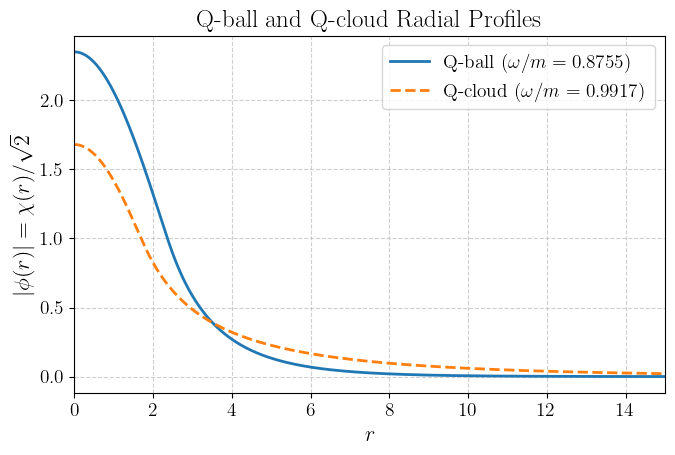

In [ ]:
# Find Q-cloud profile with matching charge
omega_cloud, qcloud_profile = build_qcloud_profile_for_charge(
    params,
    g2Q_target,
    omega_min=QCLOUD_OMEGA_MIN_RATIO * params.m,
    omega_max=QCLOUD_OMEGA_MAX_RATIO * params.m,
    n_points=QCLOUD_N_POINTS,
    phi0_cap=10.0,
    x_min=-1.0,
    x_max=6.0,
    prefer_side="+",
)

# Plot Q-ball and Q-cloud profiles
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(qball_profile.r, qball_profile.chi / np.sqrt(2), 
        label=rf"Q-ball ($\omega/m={omega_qball/params.m:.4f}$)", lw=2, color='C0')
ax.plot(qcloud_profile.r, qcloud_profile.chi / np.sqrt(2), 
        label=rf"Q-cloud ($\omega/m={omega_cloud/params.m:.4f}$)", lw=2, color='C1', linestyle='--')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$|\phi(r)| = \chi(r)/\sqrt{2}$")
ax.set_title("Q-ball and Q-cloud Radial Profiles")
ax.set_xlim(0, 15)
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


## Effective Potentials and Profiles Comparison

We compare the effective potentials $\hat{V}(|\phi|) = V(|\phi|) - \frac{1}{2}\omega^2 |\phi|^2$ for both Q-ball and Q-cloud solutions. The left panel shows the effective potentials, with vertical lines marking the field values at $r=0$ ($\phi(0)$). The right panel shows the radial profiles $|\phi(r)|$ for both solutions.

This visualization helps understand how the different frequencies $\omega$ affect the potential landscape and the resulting field configurations.


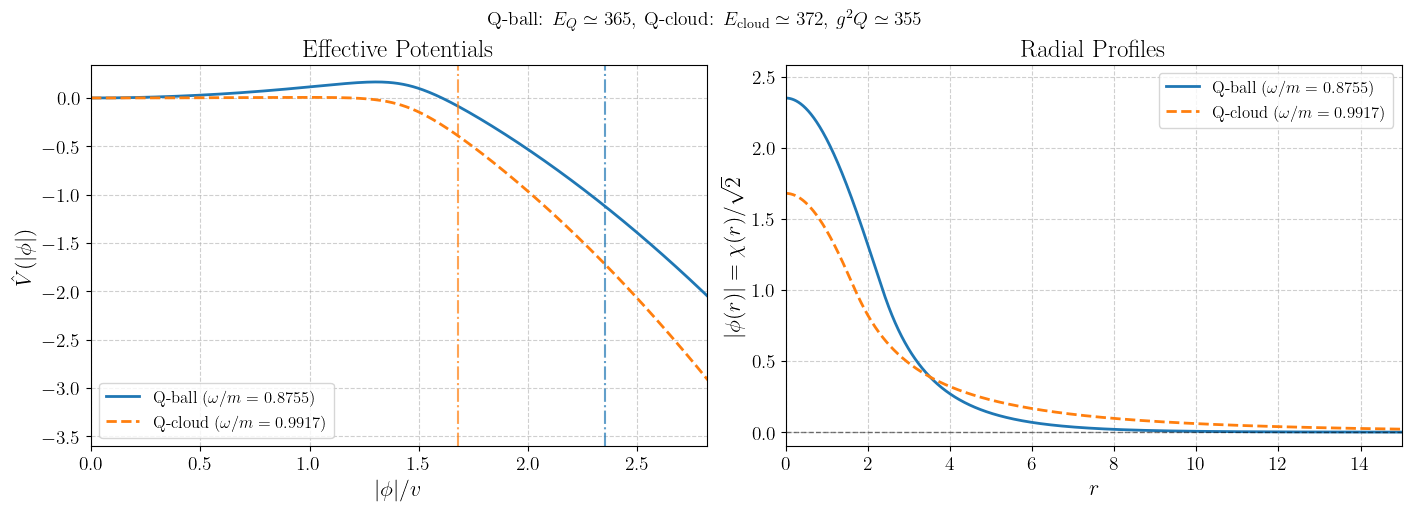

In [ ]:
# Two-panel plot: effective potentials (left) and profiles (right) for Q-ball and Q-cloud
# Compute Q-cloud energy for comparison
E_cloud = compute_energy(
    qcloud_profile.solution,
    omega=omega_cloud,
    potential_chi=V_chi
)

# Compute effective potentials for both Q-ball and Q-cloud
chis = np.linspace(0.0, 3.0 * params.v, 400)
potential_vals = np.array([V_chi(chi) for chi in chis])
effective_qball = potential_vals - 0.5 * (omega_qball ** 2) * chis ** 2
effective_qcloud = potential_vals - 0.5 * (omega_cloud ** 2) * chis ** 2

# Get phi0 values (field at r=0) for both profiles
phi0_qball = qball_profile.chi[0] / np.sqrt(2)
phi0_qcloud = qcloud_profile.chi[0] / np.sqrt(2)

# Determine x-range for left panel
xmax_left = 1.2 * max(phi0_qball, phi0_qcloud)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left panel: Effective potentials
axes[0].plot(chis / params.v, effective_qball, 
             label=rf"Q-ball ($\omega/m={omega_qball/params.m:.4f}$)", 
             lw=2, color='C0')
axes[0].plot(chis / params.v, effective_qcloud, 
             label=rf"Q-cloud ($\omega/m={omega_cloud/params.m:.4f}$)", 
             lw=2, color='C1', linestyle='--')
axes[0].set_xlabel(r"$|\phi|/v$")
axes[0].set_ylabel(r"$\hat{V}(|\phi|)$")
axes[0].set_title("Effective Potentials")
axes[0].grid(True, ls="--", alpha=0.6)
axes[0].set_xlim(0, xmax_left / params.v)
axes[0].legend(loc="best", fontsize=12)

# Mark phi(0) values
axes[0].axvline(phi0_qball / params.v, color='C0', ls='-.', lw=1.5, 
                label=rf"$\phi(0)$ Q-ball", alpha=0.7)
axes[0].axvline(phi0_qcloud / params.v, color='C1', ls='-.', lw=1.5, 
                label=rf"$\phi(0)$ Q-cloud", alpha=0.7)

# Right panel: Profiles
axes[1].plot(qball_profile.r, qball_profile.chi / np.sqrt(2), 
             label=rf"Q-ball ($\omega/m={omega_qball/params.m:.4f}$)", 
             lw=2, color='C0')
axes[1].plot(qcloud_profile.r, qcloud_profile.chi / np.sqrt(2), 
             label=rf"Q-cloud ($\omega/m={omega_cloud/params.m:.4f}$)", 
             lw=2, color='C1', linestyle='--')
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$|\phi(r)| = \chi(r)/\sqrt{2}$")
axes[1].set_title("Radial Profiles")
axes[1].axhline(0, color='k', ls='--', lw=1, alpha=0.5)
axes[1].grid(True, ls="--", alpha=0.6)
axes[1].set_xlim(0, 15)
axes[1].set_ylim(-0.1, 1.1 * max(phi0_qball, phi0_qcloud))
axes[1].legend(loc="best", fontsize=12)

# Suptitle with energies and charge
title = (rf"Q-ball: $E_Q \simeq {E_Q:.3g}$, "
         rf"Q-cloud: $E_{{\rm cloud}} \simeq {E_cloud:.3g}$, "
         rf"$g^2 Q \simeq {g2Q_target:.3g}$")
fig.suptitle(title, fontsize=14)

plt.show()


## Frequency Scan: Charge and Energy Dependence

We perform a comprehensive frequency scan to explore the full Q-ball solution space. The scan covers both the metastable branch (left branch, $\omega < \omega_c$) and the unstable branch (right branch, $\omega > \omega_c$), where $\omega_c$ is the critical frequency at which the charge $g^2 Q$ is minimized.

The plots show:
1. **Charge vs frequency**: $g^2 Q$ as a function of $\omega/m$, with the critical point $Q_c$ marked.
2. **Energy vs frequency**: $E$ as a function of $\omega/m$, showing how energy varies across the solution branches.

The critical point $(\omega_c, Q_c)$ separates the two branches and plays a crucial role in the stability analysis.


Performing frequency scan...
  Progress: 20/100 points
  Progress: 40/100 points
  Progress: 60/100 points
  Progress: 80/100 points
Scan completed: 95 successful points


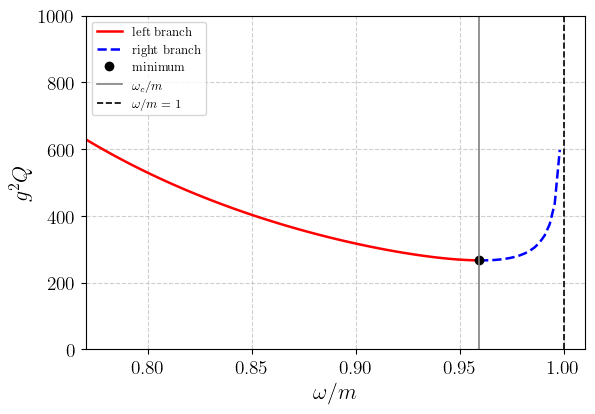

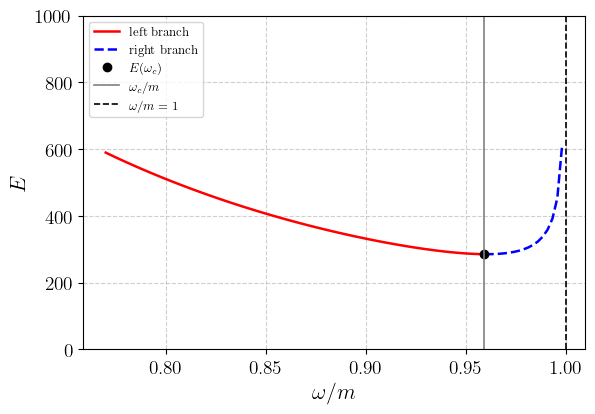

Critical point (from g^2 Q):
  ω/m   = 0.959915
  g²Q_c = 266.663344


In [ ]:
# Frequency scan: compute g²Q and E vs ω/m for Q-ball solutions
# Scan over a wide range to capture both metastable (left) and unstable (right) branches

omega_min_scan = 0.77 * params.m
omega_max_scan = 1.01 * params.m
n_points_scan = 100

wtilde_grid = np.linspace(omega_min_scan / params.m, omega_max_scan / params.m, n_points_scan)
omega_grid = wtilde_grid * params.m

g2Q_vals = []
Es_vals = []
wtilde_ok = []

print("Performing frequency scan...")
for i, omega in enumerate(omega_grid):
    try:
        profile = solve_qball_profile(
            params,
            omega,
            phi0_cap=10.0,
            x_min=-1.0,
            x_max=6.0,
            prefer_side="+",
        )
        charge = compute_dimensionless_charge(
            profile.solution, m=params.m, v=params.v, omega=omega
        )
        energy = compute_energy(
            profile.solution, omega=omega, potential_chi=V_chi
        )
        g2Q_vals.append(charge)
        Es_vals.append(energy)
        wtilde_ok.append(omega / params.m)
        if (i + 1) % 20 == 0:
            print(f"  Progress: {i+1}/{n_points_scan} points")
    except Exception as e:
        continue

print(f"Scan completed: {len(wtilde_ok)} successful points")

# Prepare data
x = np.array(wtilde_ok)              # ω/m
yQ = np.array(g2Q_vals)              # g^2 Q
yE = np.array(Es_vals)               # E(ω)

# Keep only finite points and sort by x (safer)
mask = np.isfinite(x) & np.isfinite(yQ) & np.isfinite(yE)
x, yQ, yE = x[mask], yQ[mask], yE[mask]

order = np.argsort(x)
x  = x[order]
yQ = yQ[order]
yE = yE[order]

# Find the minimum of g^2 Q (defines ω_c and (g^2 Q)_c)
imin = int(np.nanargmin(yQ))
xmin, ymin = x[imin], yQ[imin]

# ========= Plot 1: g^2 Q vs ω/m =========
plt.figure(figsize=(6.2, 4.4))

# Left of the minimum: solid red
plt.plot(x[:imin+1], yQ[:imin+1], 'r-', lw=1.8, label='left branch')

# Right of the minimum: dashed blue
plt.plot(x[imin:],  yQ[imin:],  'b--', lw=1.8, label='right branch')

# Mark the minimum point
plt.plot([xmin], [ymin], 'ko', ms=6, label='minimum')

# Vertical lines: at the minimum and at 1
plt.axvline(xmin, color='gray', ls='-',  lw=1.2, label=r'$\omega_c/m$')
plt.axvline(1.0,  color='k',    ls='--', lw=1.2, label=r'$\omega/m = 1$')

plt.xlabel(r"$\omega/m$")
plt.ylabel(r"$g^2 Q$")
plt.ylim(0, 1000)
plt.xlim(0.77, 1.01)
plt.grid(True, ls="--", alpha=0.6)
plt.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

# ========= Plot 2: E vs ω/m =========
plt.figure(figsize=(6.2, 4.4))

# stesso split a sinistra/destra del minimo in ω
plt.plot(x[:imin+1], yE[:imin+1], 'r-', lw=1.8, label='left branch')
plt.plot(x[imin:],  yE[imin:],  'b--', lw=1.8, label='right branch')

# segna il valore a ω_c
Ec = yE[imin]
plt.plot([xmin], [Ec], 'ko', ms=6, label=r'$E(\omega_c)$')

plt.axvline(xmin, color='gray', ls='-',  lw=1.2, label=r'$\omega_c/m$')
plt.axvline(1.0,  color='k',    ls='--', lw=1.2, label=r'$\omega/m = 1$')

plt.xlabel(r"$\omega/m$")
plt.ylabel(r"$E$")
plt.ylim(0, 1000)
plt.grid(True, ls="--", alpha=0.6)
plt.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

# Fit quadratico locale sul minimo di g^2 Q (come prima)
if 0 < imin < len(x) - 1:
    x_fit = x[imin-1:imin+2]
    y_fit = yQ[imin-1:imin+2]

    a, b, c = np.polyfit(x_fit, y_fit, 2)
    xmin = -b / (2 * a)
    ymin = np.polyval([a, b, c], xmin)
else:
    xmin, ymin = x[imin], yQ[imin]

print("Critical point (from g^2 Q):")
print(f"  ω/m   = {xmin:.6f}")
print(f"  g²Q_c = {ymin:.6f}")


## Stability Analysis: Normalized Energy vs Charge

We plot the normalized energy $(E-Q)/E(Q_c)$ as a function of the normalized charge $Q/Q_c$. This plot reveals important stability properties:

- **Q-cloud branch** (red, solid): Solutions with $\omega < \omega_c$ (left branch in frequency scan)
- **Q-ball branch** (blue, dashed): Solutions with $\omega > \omega_c$ (right branch in frequency scan)
- **Critical point** $Q = Q_c$: The minimum charge point
- **Absolute stability point** $Q_s/Q_c$: Where $(E-Q)/E(Q_c) = 0$, marking the transition between absolute stability and metastability

Solutions with $(E-Q)/E(Q_c) < 0$ are absolutely stable, while those with $(E-Q)/E(Q_c) > 0$ are only metastable.


Qc (in unità g^2Q)  = 266.681
Ec = E(Qc)          = 285.311
(ω/m)_c             = 0.95909091
Estimated Qs/Qc ≈ 1.603


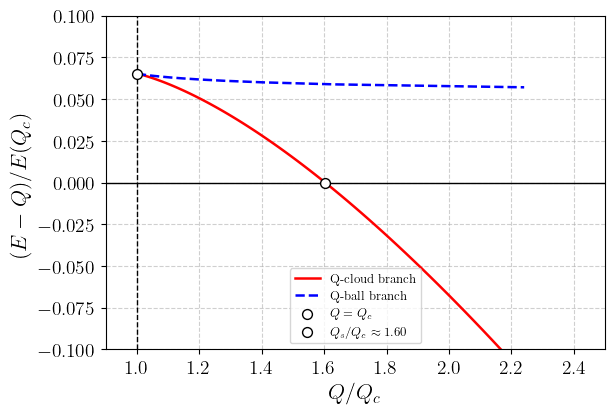

Absolute stability roughly at Q_s/Q_c ≈ 1.603226


In [ ]:
# Plot (E - Q)/E(Qc) vs Q/Qc (Figure 4 style)
# Use results from frequency scan in previous cell

# Partiamo dai risultati dello scan
# wtilde_ok : ω/m per cui il solver ha trovato una soluzione
# g2Q_vals  : g^2 Q(ω̃)
# Es_vals   : E(ω̃) sopra il vuoto

x  = np.array(wtilde_ok)        # ω/m
Q  = np.array(g2Q_vals)         # qui usiamo Q = g^2 Q (coerente col paper fino a una costante)
E  = np.array(Es_vals)          # energia sopra il vuoto

# Pulisci: punti finiti e Q>0 (escludi soluzioni banali Q≈0)
mask = np.isfinite(x) & np.isfinite(Q) & np.isfinite(E) & (Q > 0)
x, Q, E = x[mask], Q[mask], E[mask]

# Ordina in ω/m (molto importante per separare i rami)
order = np.argsort(x)
x, Q, E = x[order], Q[order], E[order]

# Trova il minimo di Q(ω̃): questo definisce Qc ed Ec
imin = int(np.argmin(Q))
Qc, Ec = Q[imin], E[imin]

print(f"Qc (in unità g^2Q)  = {Qc:.6g}")
print(f"Ec = E(Qc)          = {Ec:.6g}")
print(f"(ω/m)_c             = {x[imin]:.8f}")

# Variabili adimensionali per Fig. 4:
# X = Q/Qc, Y = (E - Q)/E(Qc) (assumendo m=1, e usando Q=g^2Q)
X = Q / Qc
Y = (E - Q) / Ec

# Separa i due rami in base al minimo in ω:
# - branch "left": ω < ω_c (Q-cloud branch)
# - branch "right": ω > ω_c (Q-ball branch)
X_left,  Y_left  = X[:imin+1], Y[:imin+1]
X_right, Y_right = X[imin:],   Y[imin:]

# (opzionale ma consigliato) ordina ogni ramo in X per avere curve monotone
orderL = np.argsort(X_left)
orderR = np.argsort(X_right)

X_left,  Y_left  = X_left[orderL],  Y_left[orderL]
X_right, Y_right = X_right[orderR], Y_right[orderR]

# Find zero crossing on left branch (absolute stability point)
Xs = np.nan
s = np.sign(Y_left)
k = np.where(s[:-1] * s[1:] < 0)[0]

if k.size:
    j = k[0]
    x1, y1 = X_left[j],   Y_left[j]
    x2, y2 = X_left[j+1], Y_left[j+1]
    Xs = x1 + (0.0 - y1) * (x2 - x1) / (y2 - y1)
    print(f"Estimated Qs/Qc ≈ {Xs:.3f}")
else:
    print("No zero crossing found on the Q-ball branch.")

# ==============================
# Plot (E - Q)/E(Qc) vs Q/Qc
# ==============================
plt.figure(figsize=(6.4, 4.4))

plt.plot(X_left,  Y_left,  'r-', lw=1.8, label='Q-cloud branch')
plt.plot(X_right, Y_right, 'b--',  lw=1.8, label='Q-ball branch')

# Punto critico Q = Qc (X=1)
plt.scatter([1.0], [Y[imin]], s=50, facecolors='white', edgecolors='k', zorder=5, label=r'$Q = Q_c$')

# Crossing di stabilità assoluta (se esiste)
if np.isfinite(Xs):
    plt.scatter([Xs], [0.0], s=50, facecolors='white', edgecolors='k', zorder=6,
                label=rf'$Q_s/Q_c \approx {Xs:.2f}$')

plt.axvline(1.0, color='k', ls='--', lw=1.0)
plt.axhline(0.0, color='k', lw=1.0)

plt.xlabel(r"$Q/Q_c$")
plt.ylabel(r"$(E - Q)/E(Q_c)$")   # con m=1 e Q ≡ g^2Q
plt.xlim(0.9, 2.5)
plt.ylim(-.1,.1)
plt.grid(True, ls="--", alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

if np.isfinite(Xs):
    print(f"Absolute stability roughly at Q_s/Q_c ≈ {Xs:.6f}")


## Unstable Eigenmode around the Q-cloud

The Q-cloud configuration is unstable and hosts a single negative eigenmode that mediates the decay towards the true vacuum. This mode is computed by linearizing the equations of motion around the Q-cloud profile and solving the radial eigenvalue problem.

The growth rate $\gamma$ (eigenvalue) determines the natural Euclidean time scale for the bounce:

$$\beta_{\rm natural} = \frac{2\pi}{\gamma}$$

This sets the characteristic size of the Euclidean time interval for the 2D bounce solution.

The eigenvalue is found using a shooting method: we solve the linearized ODE for different trial values of $\gamma$ and find the value for which the shooting function $D_p(\gamma)$ vanishes. The plot of $\log_{10}|D_p(\gamma)|$ shows the behavior of the shooting function and helps identify the eigenvalue.


In [10]:
# Compute unstable eigenmode using library function
unstable_mode = compute_unstable_mode(qcloud_profile)

# Compute natural beta from growth rate
beta_natural = 2.0 * np.pi / unstable_mode.gamma

print(f"Unstable mode computed:")
print(f"  Growth rate γ              = {unstable_mode.gamma:.6f}")
print(f"  Natural β = 2π/γ           = {beta_natural:.6f}")


Unstable mode computed:
  Growth rate γ              = 0.129338
  Natural β = 2π/γ           = 48.579430


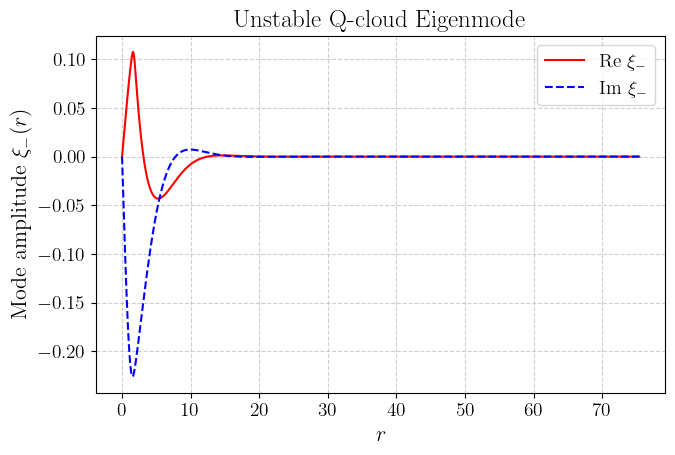

In [11]:
# Plot unstable eigenmode
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(unstable_mode.r, -unstable_mode.xi_real, 'r-', 
        label=r"Re $\xi_{-}$", lw=1.5)
ax.plot(unstable_mode.r, -unstable_mode.xi_imag, 'b--', 
        label=r"Im $\xi_{-}$", lw=1.5)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"Mode amplitude $\xi_{-}(r)$")
ax.set_title("Unstable Q-cloud Eigenmode")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Shooting Function for Eigenvalue Search

The shooting function $D_p(\gamma)$ is computed during the eigenvalue search. It measures the mismatch in boundary conditions for the linearized mode equation. The eigenvalue $\gamma$ is found where $D_p(\gamma) = 0$.

The plot shows $\log_{10}|D_p(\gamma)|$ as a function of $\gamma$. The zero crossing (sign change) identifies the interval containing the eigenvalue, which is then refined using root finding.


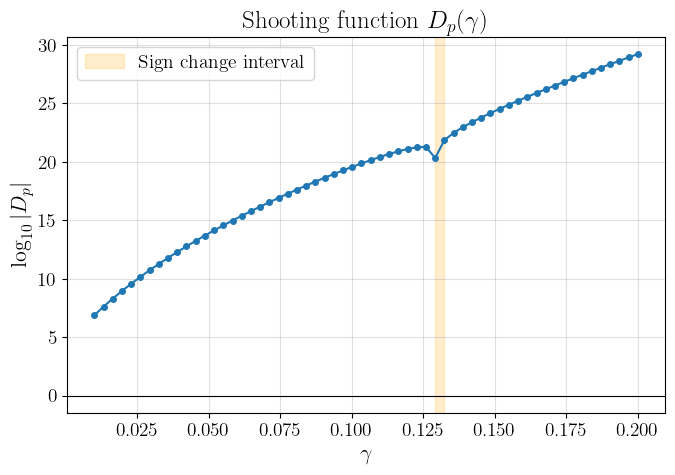

In [12]:
# Plot shooting function D_p(gamma) using values from compute_unstable_mode
# The unstable_mode object now contains gamma_grid and Dp_vals

import matplotlib.pyplot as plt

# Extract gamma_grid and Dp_vals from unstable_mode (already computed in previous cell)
gamma_grid = unstable_mode.gamma_grid
Dp_vals = unstable_mode.Dp_vals

# Find bracket for sign change (if not already found)
bracket = None
if gamma_grid is not None and Dp_vals is not None:
    for i in range(len(gamma_grid) - 1):
        if np.sign(Dp_vals[i]) != np.sign(Dp_vals[i + 1]):
            bracket = (gamma_grid[i], gamma_grid[i + 1])
            break

plt.figure(figsize=(7,5))
plt.plot(gamma_grid, np.log10(np.abs(Dp_vals) + 1e-300), '-o', lw=1.5, ms=4)
plt.axhline(0, color='k', lw=0.8)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\log_{10}|D_p|$')
plt.title(r'Shooting function $D_p(\gamma)$')
plt.grid(True, alpha=0.4)

# Optional: mark bracket region if found
if bracket is not None:
    plt.axvspan(bracket[0], bracket[1], color='orange', alpha=0.2, label='Sign change interval')
    plt.legend()

plt.tight_layout()
plt.show()


## Building the Two-dimensional Ansatz

With the Q-cloud profile and its unstable mode, we assemble the Euclidean-time dependent initial ansatz for the full 2D bounce solution. The ansatz displaces the Q-cloud configuration along the negative eigenmode, creating a time-dependent configuration that connects to the true vacuum.

The ansatz is constructed on a staggered grid:
- **Radial grid**: $r_j = dr \cdot (j+1)$ for $j=0,\ldots,N_r-1$
- **Tau grid**: $\tau_i = -dt \cdot (i+1/2)$ for $i=0,\ldots,N_\tau-1$ (half-interval $-\beta/2 < \tau < 0$)

The amplitude parameter $A_{-}$ controls the displacement along the negative mode. We use the configuration value `ANSATZ_AMPLITUDE`.


In [13]:
# Build grid using natural beta from growth rate
beta_ansatz = 2.0 * np.pi / unstable_mode.gamma
grid = build_grid(Nr=GRID_NR, Ntau=GRID_NTAU, Lr=GRID_LR, beta=beta_ansatz)

# Build negative mode ansatz using configuration parameters
ansatz = build_negative_mode_ansatz(
    profile=qcloud_profile,
    mode=unstable_mode,
    grid=grid,
    omega_reference=omega_cloud,  # Use omega_cloud for Q-cloud ansatz
    amplitude=ANSATZ_AMPLITUDE,
    cosh_scale=ANSATZ_COSH_SCALE,
    envelope_width=None,
    flip_sign=True,
    center_at_cloud=True,
    decrease_towards_zero=False,
)

# Extract fields and compute density
phi_ansatz = ansatz.phi
phibar_ansatz = ansatz.phibar
s_ansatz = np.maximum(np.real(phi_ansatz * phibar_ansatz), 0.0)
rho_ansatz = np.sqrt(s_ansatz)

print(f"2D ansatz constructed:")
print(f"  Grid shape: (Nr={grid.Nr}, Ntau={grid.Ntau})")
print(f"  Field shape: {phi_ansatz.shape}")
print(f"  Beta = {beta_ansatz:.6f}")
print(f"  Lr = {GRID_LR:.1f}")


2D ansatz constructed:
  Grid shape: (Nr=150, Ntau=300)
  Field shape: (150, 300)
  Beta = 48.579430
  Lr = 10.0


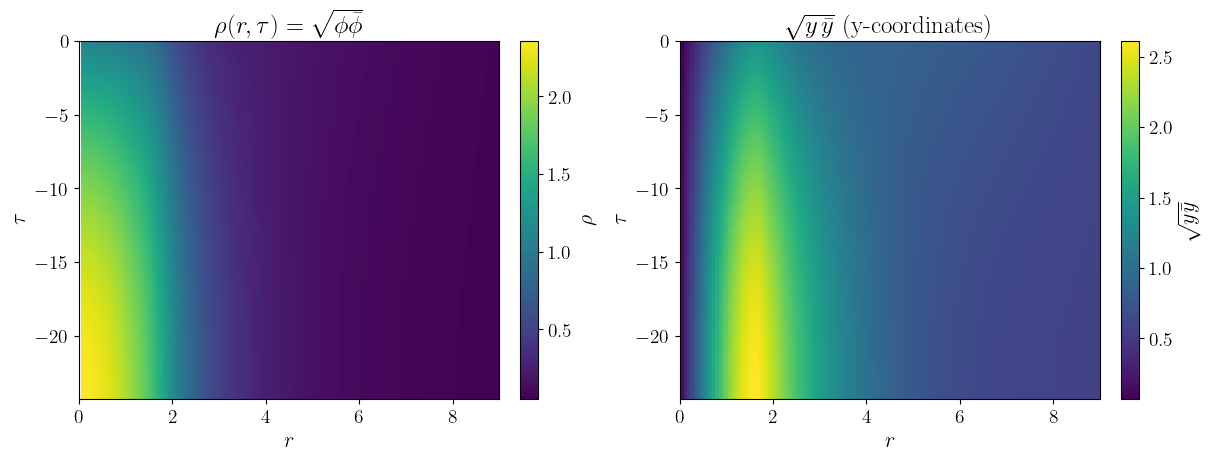

In [ ]:
# Visualize 2D ansatz density
R, T = np.meshgrid(grid.r, grid.tau, indexing="xy")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: density in phi coordinates
cf0 = axes[0].pcolormesh(R, T, rho_ansatz.T, shading="auto", cmap="viridis")
axes[0].set_title(r"$\rho(r,\tau) = \sqrt{\phi\bar\phi}$")
axes[0].set_xlabel(r"$r$")
axes[0].set_xlim(0, 9)
axes[0].set_ylabel(r"$\tau$")
fig.colorbar(cf0, ax=axes[0], label=r"$\rho$")

# Right: density in y coordinates (diagnostic)
y_ansatz, ybar_ansatz = ansatz.y, ansatz.ybar
rho_y = np.sqrt(np.maximum((y_ansatz * ybar_ansatz).real, 0.0))

cf1 = axes[1].pcolormesh(R, T, rho_y.T, shading="auto", cmap="viridis")
axes[1].set_title(r"$\sqrt{y\,\bar y}$ (y-coordinates)")
axes[1].set_xlabel(r"$r$")
axes[1].set_xlim(0, 9)
axes[1].set_ylabel(r"$\tau$")
fig.colorbar(cf1, ax=axes[1], label=r"$\sqrt{y\bar y}$")

plt.show()


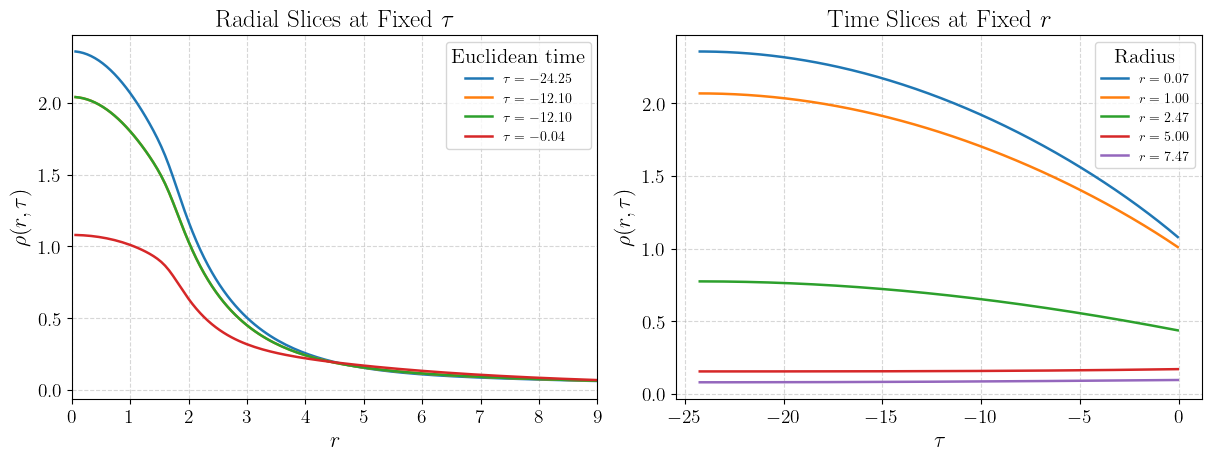

In [15]:
# Diagnostic: plot slices of the ansatz density
rs = grid.r
taus = grid.tau

# Select representative tau slices
tau_targets = [grid.tau.min(), grid.tau.min() / 2.0, -beta_ansatz / 4.0, 0.0]
tau_indices = [int(np.argmin(np.abs(taus - tau_val))) for tau_val in tau_targets]

# Select representative radial locations
r_targets = [0.0, 1.0, 2.5, 5.0, 7.5]
r_indices = [int(np.argmin(np.abs(rs - r_val))) for r_val in r_targets]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: radial slices at fixed tau
for tau_idx in tau_indices:
    label = rf"$\tau = {taus[tau_idx]:.2f}$"
    axes[0].plot(rs, rho_ansatz[:, tau_idx], lw=1.8, label=label)
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\rho(r,\tau)$")
axes[0].set_title(r"Radial Slices at Fixed $\tau$")
axes[0].set_xlim(0, 9)
axes[0].grid(True, ls="--", alpha=0.5)
axes[0].legend(title="Euclidean time", loc="best", fontsize=10)

# Right: tau slices at fixed r
for r_idx in r_indices:
    label = rf"$r = {rs[r_idx]:.2f}$"
    axes[1].plot(taus, rho_ansatz[r_idx, :], lw=1.8, label=label)
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel(r"$\rho(r,\tau)$")
axes[1].set_title(r"Time Slices at Fixed $r$")
axes[1].grid(True, ls="--", alpha=0.5)
axes[1].legend(title="Radius", loc="best", fontsize=10)

plt.show()


## Alternative Ansatz: Custom Density Profile

As an alternative to the negative-mode ansatz, we can construct a custom ansatz using a separable form $\rho(r,\tau) = A(r) \cdot f(\tau)$ where $f(\tau)$ transitions from a plateau to zero. This provides another starting point for the 2D solver.


In [16]:
# Build alternative custom ansatz (optional - for comparison)
ansatz_custom = build_custom_rho_ansatz_qball2d(
    grid=grid,
    omega=omega_cloud,
    profile=qcloud_profile,
    sigma_r=3.0,                    # Radial width
    tau_center=grid.tau.min() / 4,  # Transition center in tau
    tau_width=6.0,                  # Transition width
    amplitude_scale=1.2,             # Overall amplitude scaling
)

# Extract fields
phi_custom = ansatz_custom.phi
phibar_custom = ansatz_custom.phibar
s_custom = np.maximum(np.real(phi_custom * phibar_custom), 0.0)
rho_custom = np.sqrt(s_custom)

print(f"Custom ansatz constructed:")
print(f"  Field shape: {phi_custom.shape}")
print(f"  Uses separable form: ρ(r,τ) = A(r) · f(τ)")


Custom ansatz constructed:
  Field shape: (150, 300)
  Uses separable form: ρ(r,τ) = A(r) · f(τ)


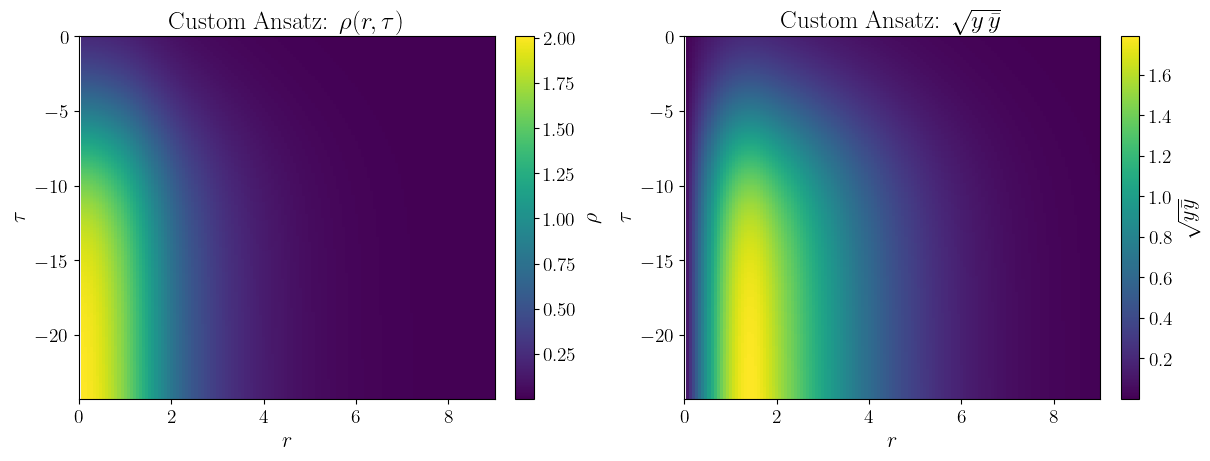

In [ ]:
# Visualize custom ansatz density
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: density in phi coordinates
cf0 = axes[0].pcolormesh(R, T, rho_custom.T, shading="auto", cmap="viridis")
axes[0].set_title(r"Custom Ansatz: $\rho(r,\tau)$")
axes[0].set_xlabel(r"$r$")
axes[0].set_xlim(0, 9)
axes[0].set_ylabel(r"$\tau$")
fig.colorbar(cf0, ax=axes[0], label=r"$\rho$")

# Right: density in y coordinates
y_custom, ybar_custom = ansatz_custom.y, ansatz_custom.ybar
rho_y_custom = np.sqrt(np.maximum((y_custom * ybar_custom).real, 0.0))

cf1 = axes[1].pcolormesh(R, T, rho_y_custom.T, shading="auto", cmap="viridis")
axes[1].set_title(r"Custom Ansatz: $\sqrt{y\,\bar y}$")
axes[1].set_xlabel(r"$r$")
axes[1].set_xlim(0, 9)
axes[1].set_ylabel(r"$\tau$")
fig.colorbar(cf1, ax=axes[1], label=r"$\sqrt{y\bar y}$")

plt.show()


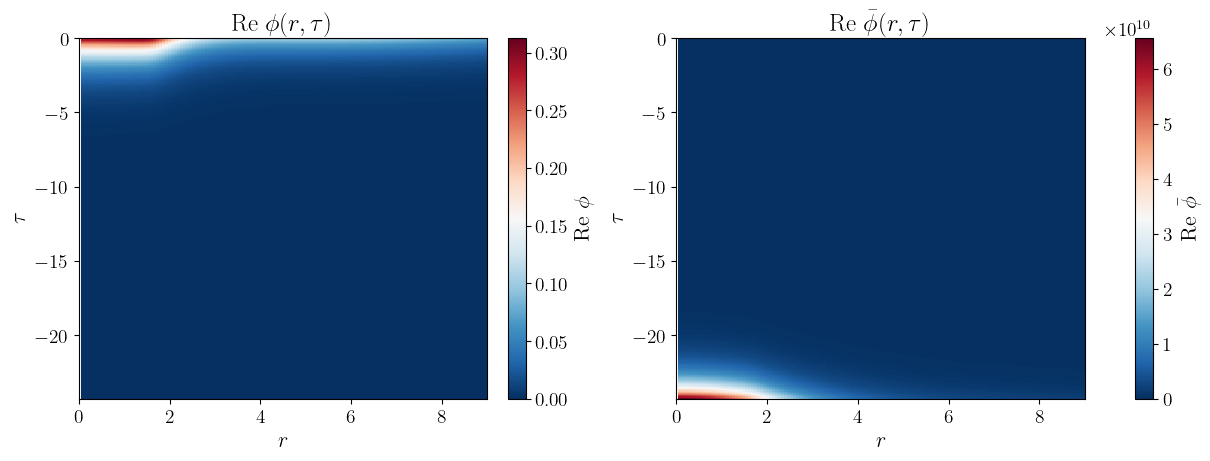

In [18]:
# Visualize real parts of complex fields
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: Re(φ)
cf0 = axes[0].pcolormesh(R, T, phi_ansatz.T.real, shading="auto", cmap="RdBu_r")
axes[0].set_title(r"Re $\phi(r,\tau)$")
axes[0].set_xlabel(r"$r$")
axes[0].set_xlim(0, 9)
axes[0].set_ylabel(r"$\tau$")
fig.colorbar(cf0, ax=axes[0], label=r"Re $\phi$")

# Right: Re(φ̄)
cf1 = axes[1].pcolormesh(R, T, phibar_ansatz.T.real, shading="auto", cmap="RdBu_r")
axes[1].set_title(r"Re $\bar\phi(r,\tau)$")
axes[1].set_xlabel(r"$r$")
axes[1].set_xlim(0, 9)
axes[1].set_ylabel(r"$\tau$")
fig.colorbar(cf1, ax=axes[1], label=r"Re $\bar\phi$")

plt.show()

## Summary and Reproducibility

### Key Results

This notebook demonstrates the complete workflow for preparing Q-ball bounce solutions:

1. **Q-ball profile**: Solved at frequency $\omega/m = 0.8755$ with charge $g^2 Q$ and energy $E_Q$
2. **Q-cloud profile**: Found matching charge configuration at higher frequency $\omega/m \approx 0.99$
3. **Frequency scan**: Explored the full solution space, identifying the critical point $(\omega_c, Q_c)$
4. **Stability analysis**: Analyzed stability properties using normalized energy vs charge plot
5. **Unstable mode**: Computed growth rate $\gamma$ determining natural Euclidean time scale $\beta = 2\pi/\gamma$
6. **Shooting function**: Visualized the eigenvalue search process
7. **2D ansatz**: Constructed initial guess for full bounce solution

### Workflow Summary

**Configuration and Setup:**
- Model parameters: $m=1$, $v=1$, $b=8$
- Q-ball frequency: $\omega/m = 0.8755$ (metastable branch)
- Grid parameters for 2D ansatz: $N_r=150$, $N_\tau=300$, $L_r=10$

**Key Computations:**
- Q-ball and Q-cloud profiles using `solve_qball_profile()` and `build_qcloud_profile_for_charge()`
- Frequency scan over $\omega/m \in [0.77, 1.01]$ to map solution branches
- Critical point identification via charge minimization
- Unstable mode computation using shooting method
- 2D ansatz construction using negative mode displacement

**Visualizations:**
- Potential and effective potential plots
- Q-ball and Q-cloud profile comparisons
- Two-panel plots: effective potentials and radial profiles
- Frequency scan plots: charge and energy vs $\omega/m$
- Stability plot: $(E-Q)/E(Q_c)$ vs $Q/Q_c$
- Unstable mode eigenfunction plots
- Shooting function visualization
- 2D ansatz density and field visualizations

All computations use library functions from `Q_ball_finder/` for modularity and reproducibility.


In [19]:
# Reproducibility information
import sys
import numpy as np
import matplotlib

print("=" * 60)
print("Reproducibility Information")
print("=" * 60)
print(f"Python version:     {sys.version.split()[0]}")
print(f"NumPy version:      {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"\nConfiguration used:")
print(f"  Model: m={M}, v={V}, b={B}")
print(f"  Q-ball: ω/m = {OMEGA_QBALL_RATIO}")
print(f"  Grid: Nr={GRID_NR}, Ntau={GRID_NTAU}, Lr={GRID_LR}")
print(f"\nKey results:")
print(f"  g²Q (target charge) = {g2Q_target:.6f}")
print(f"  E_Q (Q-ball energy) = {E_Q:.6f}")
print(f"  E_cloud             = {E_cloud:.6f}")
print(f"  γ (growth rate)     = {unstable_mode.gamma:.6f}")
print(f"  β_natural           = {beta_natural:.6f}")
print("=" * 60)

Reproducibility Information
Python version:     3.12.3
NumPy version:      2.3.4
Matplotlib version: 3.10.7

Configuration used:
  Model: m=1.0, v=1.0, b=8.0
  Q-ball: ω/m = 0.8755
  Grid: Nr=150, Ntau=300, Lr=10.0

Key results:
  g²Q (target charge) = 354.631864
  E_Q (Q-ball energy) = 365.115638
  E_cloud             = 371.919066
  γ (growth rate)     = 0.129338
  β_natural           = 48.579430
